In [ ]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("mediAI Day 02 environment is ready")

ModuleNotFoundError: No module named 'rdkit'

In [ ]:
%pip install -q rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 35.8 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("mediAI Day 02 environment is ready")

mediAI Day 02 environment is ready


In [ ]:
from rdkit.Chem import rdFingerprintGenerator

# Same Day 01 molecule set
molecules = {
    "Aspirin": "CC(=O)Oc1ccccc1C(=O)O",
    "Paracetamol": "CC(=O)NC1=CC=C(O)C=C1",
    "Caffeine": "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Metformin": "CN(C)C(=N)NC(=N)N"
}

# Convert SMILES text to RDKit molecule objects
mol_objects = {}

for name, smiles in molecules.items():
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        print(f"Invalid SMILES found for: {name}")
    else:
        mol_objects[name] = mol

print(f"Valid molecules loaded: {len(mol_objects)}")
print("Molecules:", list(mol_objects.keys()))

# Create Morgan fingerprint generator
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

# Create a digital fingerprint for each molecule
fingerprints = {
    name: morgan_generator.GetFingerprint(mol)
    for name, mol in mol_objects.items()
}

print(f"Morgan fingerprints created: {len(fingerprints)}")

Valid molecules loaded: 5
Molecules: ['Aspirin', 'Paracetamol', 'Caffeine', 'Ibuprofen', 'Metformin']
Morgan fingerprints created: 5


In [ ]:
from itertools import combinations

# Molecule names in one list
molecule_names = list(fingerprints.keys())

# Empty similarity matrix
similarity_matrix = np.zeros((len(molecule_names), len(molecule_names)))

# Calculate every molecule-to-molecule similarity score
for i, name_1 in enumerate(molecule_names):
    for j, name_2 in enumerate(molecule_names):
        similarity_score = DataStructs.TanimotoSimilarity(
            fingerprints[name_1],
            fingerprints[name_2]
        )
        similarity_matrix[i, j] = round(similarity_score, 3)

# Convert to a readable table
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=molecule_names,
    columns=molecule_names
)

display(similarity_df)

# Find the highest similarity pair, excluding same-molecule comparisons
pair_scores = []

for molecule_1, molecule_2 in combinations(molecule_names, 2):
    score = DataStructs.TanimotoSimilarity(
        fingerprints[molecule_1],
        fingerprints[molecule_2]
    )
    pair_scores.append((molecule_1, molecule_2, round(score, 3)))

pair_scores.sort(key=lambda x: x[2], reverse=True)

print("Most structurally similar pair in this Day 02 set:")
print(f"{pair_scores[0][0]} vs {pair_scores[0][1]} → Tanimoto score: {pair_scores[0][2]}")

,Aspirin,Paracetamol,Caffeine,Ibuprofen,Metformin
Aspirin,1.000,0.222,0.089,0.195,0.051
Paracetamol,0.222,1.000,0.098,0.184,0.088
Caffeine,0.089,0.098,1.000,0.087,0.024
Ibuprofen,0.195,0.184,0.087,1.000,0.050
Metformin,0.051,0.088,0.024,0.050,1.000


Most structurally similar pair in this Day 02 set:
Aspirin vs Paracetamol → Tanimoto score: 0.222


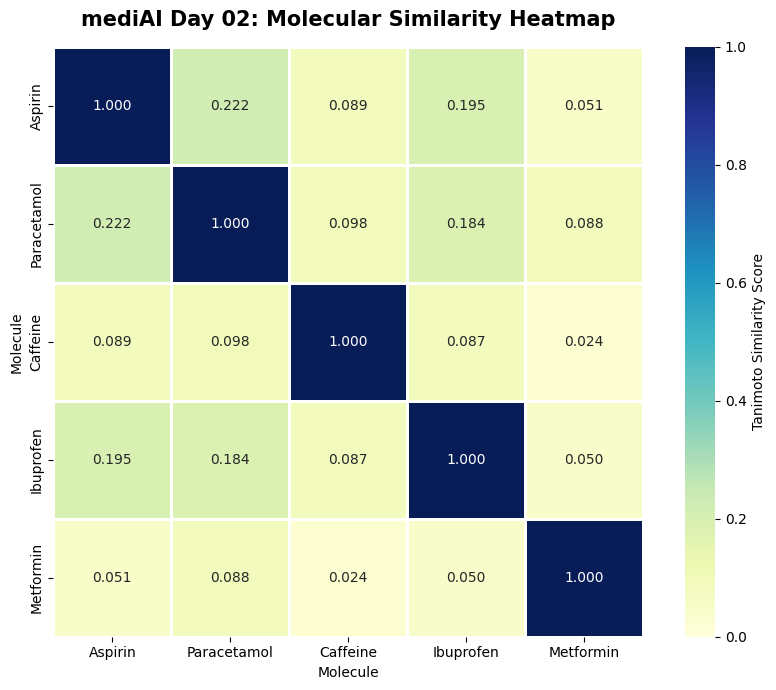

Heatmap created successfully: day02_tanimoto_similarity_heatmap.png


In [ ]:
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
    similarity_df,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Tanimoto Similarity Score"}
)

plt.title(
    "mediAI Day 02: Molecular Similarity Heatmap",
    fontsize=15,
    fontweight="bold",
    pad=15
)

plt.xlabel("Molecule")
plt.ylabel("Molecule")

heatmap_filename = "day02_tanimoto_similarity_heatmap.png"

plt.tight_layout()
plt.savefig(heatmap_filename, dpi=300, bbox_inches="tight")
plt.show()

print(f"Heatmap created successfully: {heatmap_filename}")

In [ ]:
# Convert pair scores into a ranked DataFrame
pair_df = pd.DataFrame(
    pair_scores,
    columns=["Molecule_1", "Molecule_2", "Tanimoto_Similarity"]
)

# Highest similarity pair first
pair_df = pair_df.sort_values(
    by="Tanimoto_Similarity",
    ascending=False
).reset_index(drop=True)

# Add a simple structure-similarity note
def similarity_note(score):
    if score >= 0.70:
        return "High structural similarity"
    elif score >= 0.40:
        return "Moderate structural similarity"
    elif score >= 0.20:
        return "Low-to-moderate structural similarity"
    else:
        return "Low structural similarity"

pair_df["Interpretation"] = pair_df["Tanimoto_Similarity"].apply(
    similarity_note
)

display(pair_df)

# Save final Day 02 result files
similarity_df.to_csv(
    "day02_tanimoto_similarity_matrix.csv"
)

pair_df.to_csv(
    "day02_tanimoto_pair_ranking.csv",
    index=False
)

print("Day 02 CSV files created successfully:")
print("- day02_tanimoto_similarity_matrix.csv")
print("- day02_tanimoto_pair_ranking.csv")

,Molecule_1,Molecule_2,Tanimoto_Similarity,Interpretation
0,Aspirin,Paracetamol,0.222,Low-to-moderate structural similarity
1,Aspirin,Ibuprofen,0.195,Low structural similarity
2,Paracetamol,Ibuprofen,0.184,Low structural similarity
3,Paracetamol,Caffeine,0.098,Low structural similarity
4,Aspirin,Caffeine,0.089,Low structural similarity
5,Paracetamol,Metformin,0.088,Low structural similarity
6,Caffeine,Ibuprofen,0.087,Low structural similarity
7,Aspirin,Metformin,0.051,Low structural similarity
8,Ibuprofen,Metformin,0.050,Low structural similarity
9,Caffeine,Metformin,0.024,Low structural similarity


Day 02 CSV files created successfully:
- day02_tanimoto_similarity_matrix.csv
- day02_tanimoto_pair_ranking.csv


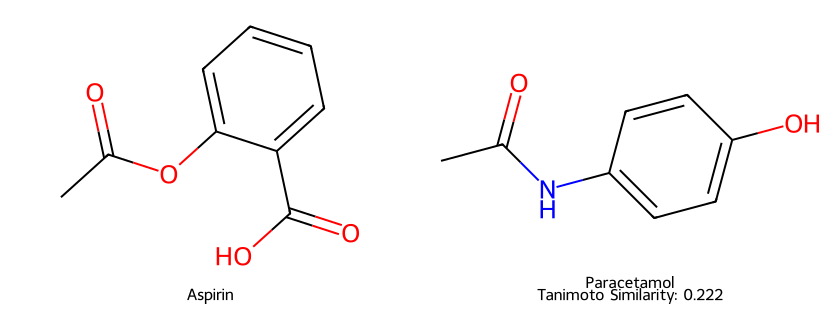

AttributeError: 'Image' object has no attribute 'save'

In [ ]:
# Get the highest similarity pair
top_pair = pair_df.iloc[0]

molecule_1 = top_pair["Molecule_1"]
molecule_2 = top_pair["Molecule_2"]
top_score = top_pair["Tanimoto_Similarity"]

# Create side-by-side structure image
top_pair_image = Draw.MolsToGridImage(
    [mol_objects[molecule_1], mol_objects[molecule_2]],
    molsPerRow=2,
    subImgSize=(420, 320),
    legends=[
        molecule_1,
        f"{molecule_2}\nTanimoto Similarity: {top_score:.3f}"
    ]
)

display(top_pair_image)

# Save image for GitHub and Video 02
pair_image_filename = "day02_top_similarity_pair.png"
top_pair_image.save(pair_image_filename)

print(f"Top-pair visual created successfully: {pair_image_filename}")

In [ ]:
pair_image_filename = "day02_top_similarity_pair.png"

with open(pair_image_filename, "wb") as file:
    file.write(top_pair_image.data)

print(f"Top-pair visual saved successfully: {pair_image_filename}")

Top-pair visual saved successfully: day02_top_similarity_pair.png


In [ ]:
import zipfile
from google.colab import files

# All Day 02 output files
day02_files = [
    "day02_tanimoto_similarity_heatmap.png",
    "day02_tanimoto_similarity_matrix.csv",
    "day02_tanimoto_pair_ranking.csv",
    "day02_top_similarity_pair.png"
]

zip_filename = "mediAI_day02_results.zip"

# Create one ZIP package
with zipfile.ZipFile(zip_filename, "w") as zip_file:
    for file_name in day02_files:
        zip_file.write(file_name)

print(f"Results package created: {zip_filename}")

# Download ZIP package
files.download(zip_filename)

Results package created: mediAI_day02_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>